# NB06 — REE-AMD MAG case study (n=37)

**Project**: lanthanide_methylotrophy_atlas
**Goal**: Descriptive characterization of the 37 MAGs from rare earth elements-acid mine drainage (REE-AMD) contaminated river water samples in `kbase_ke_pangenome.ncbi_env`. This is a small-N case study (per plan v3, NOT a formal statistical test); the question is *what is biologically present in REE-impacted aquatic environments, and how does it relate to the lanthanide-MDH cassette?*

**Inputs** (Spark required for the bakta product enrichment):
- `data/genome_environment_classes.csv` — genome→env mapping incl. ree_impacted
- `data/genome_marker_matrix.csv` — marker presence
- `kbase_ke_pangenome.bakta_annotations` — functional products (Spark)
- `kbase_ke_pangenome.gene_genecluster_junction`, `gene` — gene→genome lookup

**Outputs**:
- `data/ree_amd_mag_inventory.csv`
- `data/ree_amd_top_bakta_products.csv`
- `figures/ree_amd_taxonomy.png`
- `figures/ree_amd_marker_presence.png`

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.sql import functions as F

try:
    spark = get_spark_session()
except NameError:
    from berdl_notebook_utils.setup_spark_session import get_spark_session
    spark = get_spark_session()

DATA = Path("../data")
FIG = Path("../figures")
print(spark.version)


4.0.1


## 1. Load 37 REE-AMD MAGs

In [2]:
env = pd.read_csv(DATA / "genome_environment_classes.csv")
ree = env[env["env_class"] == "ree_impacted"].copy()
print(f"REE-impacted genomes: {len(ree)}")
print(ree[["genome_id", "phylum", "class", "family", "genus"]].to_string(index=False))


REE-impacted genomes: 37
         genome_id             phylum                  class                  family               genus
GB_GCA_018968895.1  p__Pseudomonadota c__Gammaproteobacteria   f__Burkholderiaceae_A          g__UBA3064
GB_GCA_018970705.1  p__Pseudomonadota c__Gammaproteobacteria   f__Burkholderiaceae_A          g__UBA3064
GB_GCA_018969285.1 p__Cyanobacteriota      c__Cyanobacteriia          f__Nostocaceae     g__Raphidiopsis
GB_GCA_018969965.1  p__Pseudomonadota c__Gammaproteobacteria   f__Burkholderiaceae_A           g__UBA954
GB_GCA_018970385.1 p__Cyanobacteriota      c__Cyanobacteriia             f__CAIUCS01         g__CAIUCS01
GB_GCA_018969125.1  p__Pseudomonadota c__Alphaproteobacteria     f__Acetobacteraceae     g__Acidiphilium
GB_GCA_018970295.1  p__Pseudomonadota c__Alphaproteobacteria       f__Rickettsiaceae          g__Megaira
GB_GCA_018970655.1   p__Chloroflexota             c__UBA2235             f__UBA12225         g__CAILQO01
GB_GCA_018969305.1  p__Actinom

## 2. Cassette presence in REE-AMD MAGs

In [3]:
matrix = pd.read_csv(DATA / "genome_marker_matrix.csv")
ree_inv = ree[["genome_id", "phylum", "class", "family", "genus"]].merge(matrix, on="genome_id", how="left")
marker_cols = [c for c in matrix.columns if c != "genome_id"]
ree_inv[marker_cols] = ree_inv[marker_cols].fillna(0).astype(int)
print(f"REE-AMD genomes carrying any xoxF (either source): {int(ree_inv['xoxF_either'].sum())}/{len(ree_inv)}")
print(f"REE-AMD genomes carrying bakta lanmodulin: {int(ree_inv['lanM_bakta'].sum())}/{len(ree_inv)}")
print(f"REE-AMD genomes carrying xoxJ (bakta): {int(ree_inv['xoxJ_bakta'].sum())}/{len(ree_inv)}")
print()
print("Per-genome marker presence:")
key_cols = ["genome_id", "phylum", "family", "genus", "xoxF_either", "xoxJ_bakta", "lanM_bakta", "mxaF_eggnog", "pqqB_eggnog", "pqqC_eggnog"]
print(ree_inv[key_cols].sort_values(["xoxF_either", "phylum"], ascending=[False, True]).to_string(index=False))

ree_inv.attrs = {}
ree_inv.to_csv(DATA / "ree_amd_mag_inventory.csv", index=False)


REE-AMD genomes carrying any xoxF (either source): 4/37
REE-AMD genomes carrying bakta lanmodulin: 0/37
REE-AMD genomes carrying xoxJ (bakta): 0/37

Per-genome marker presence:
         genome_id             phylum                  family               genus  xoxF_either  xoxJ_bakta  lanM_bakta  mxaF_eggnog  pqqB_eggnog  pqqC_eggnog
GB_GCA_018969125.1  p__Pseudomonadota     f__Acetobacteraceae     g__Acidiphilium            1           0           0            0            0            0
GB_GCA_018969085.1  p__Pseudomonadota   f__Burkholderiaceae_B    g__Limnohabitans            1           0           0            0            0            0
GB_GCA_018971145.1  p__Pseudomonadota     f__Burkholderiaceae        g__Trinickia            1           0           0            0            1            1
GB_GCA_018970795.1  p__Pseudomonadota     f__Burkholderiaceae           g__SYFN01            1           0           0            0            0            1
GB_GCA_018969305.1  p__Actinomyce

## 3. Top bakta products in REE-AMD MAGs (Spark query)

Identify the most common functional products encoded in these genomes — focus on metal/acidophily-relevant categories.

In [4]:
ree_genome_ids = ree["genome_id"].tolist()
ree_genome_df = spark.createDataFrame(pd.DataFrame({"genome_id": ree_genome_ids}))

gene = spark.table("kbase_ke_pangenome.gene")
junction = spark.table("kbase_ke_pangenome.gene_genecluster_junction")
bakta = spark.table("kbase_ke_pangenome.bakta_annotations")

ree_products = (
    gene.join(ree_genome_df, "genome_id", "inner")
    .select("gene_id", "genome_id")
    .join(junction, "gene_id")
    .select("gene_cluster_id", "genome_id")
    .join(bakta, "gene_cluster_id")
    .select("genome_id", "product")
)
# Counts: how many DISTINCT GENOMES (out of 37) carry each product?
product_genome_counts = (
    ree_products.dropDuplicates(["genome_id", "product"])
    .groupBy("product")
    .count()
    .toPandas()
)
product_genome_counts.attrs = {}
product_genome_counts = product_genome_counts.sort_values("count", ascending=False)
print(f"Distinct bakta product strings in REE-AMD MAGs: {len(product_genome_counts):,}")
print(product_genome_counts.head(40).to_string(index=False))


Distinct bakta product strings in REE-AMD MAGs: 13,515
                                               product  count
                                  hypothetical protein     37
                   ABC transporter ATP-binding protein     37
                                      histidine kinase     37
                                           Lipoprotein     37
                                       MFS transporter     36
                              ABC transporter permease     36
                            MBL fold metallo-hydrolase     35
                                  DNA gyrase subunit A     35
                   Peptidyl-prolyl cis-trans isomerase     34
             DNA-directed RNA polymerase subunit alpha     34
                       GNAT family N-acetyltransferase     34
                                Pseudouridine synthase     34
                   Cell shape-determining protein MreB     34
                                      DNA polymerase I     34
               

## 4. Filter for metal/acidophily/REE-relevant products

In [5]:
import re
RELEVANT_RX = (
    r"lanthan|rare.earth|xoxf|lanmod|cerium|"
    r"acid resist|proton|atpase|"
    r"mercury|arsen|cadmium|copper|zinc|nickel|cobalt|chromium|cuprous|"
    r"siderop|iron transport|fe-s|hemerythrin|"
    r"sulfur oxid|sulfide|sulfate reduc|"
    r"oxidative stress|catalase|peroxidase|superoxide|"
    r"dna repair|recombinase|"
    r"heavy metal|metallochaperone|metal efflux|cation efflux|copa|cuea|merr|nccx|cusa|merp|smtb"
)
mask = product_genome_counts["product"].str.lower().str.contains(RELEVANT_RX, regex=True, na=False)
relevant = product_genome_counts[mask].sort_values("count", ascending=False)
print(f"Metal/acidophily/REE-relevant products: {len(relevant):,}")
print(relevant.head(40).to_string(index=False))

relevant.to_csv(DATA / "ree_amd_top_bakta_products.csv", index=False)


Metal/acidophily/REE-relevant products: 536
                                                                                product  count
                                                                DNA repair protein RecN     33
                                                                DNA repair protein RadA     32
                                                                DNA repair protein RecO     31
                                                ATP-dependent zinc metalloprotease FtsH     31
                                                  MerR family transcriptional regulator     30
                                                                       recombinase RecA     28
                                                                      AAA family ATPase     27
                                        proton-translocating NAD(P)(+) transhydrogenase     27
                                                            redox-regulated ATPase YchF     26
      

## 5. Figures

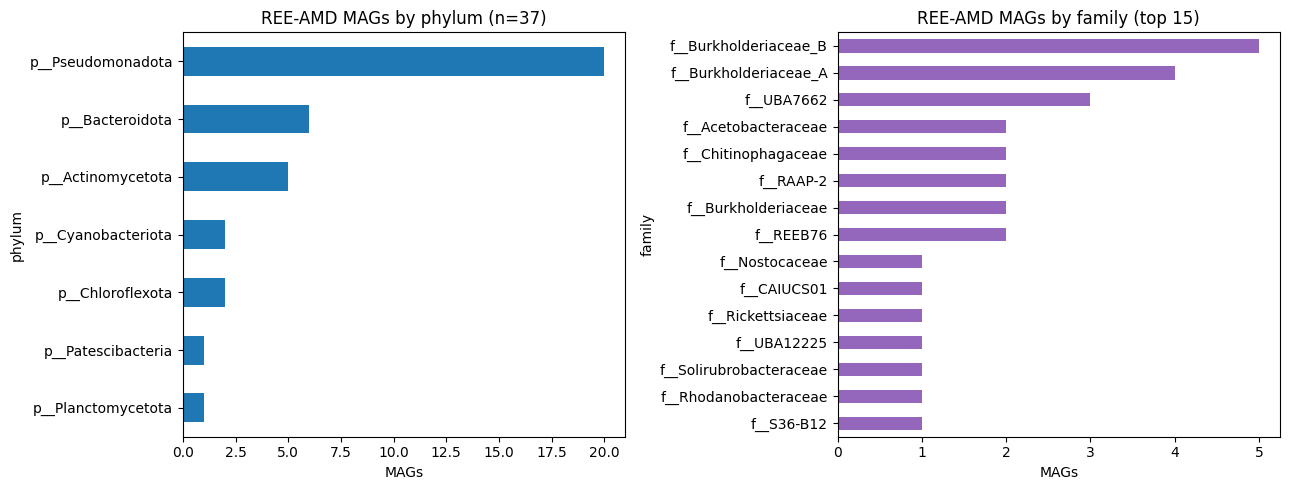

In [6]:
# Figure 1: Taxonomy
phylum_counts = ree_inv["phylum"].value_counts()
family_counts = ree_inv["family"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
phylum_counts.plot(kind="barh", ax=axes[0], color="#1f77b4")
axes[0].invert_yaxis()
axes[0].set_xlabel("MAGs")
axes[0].set_title(f"REE-AMD MAGs by phylum (n={len(ree_inv)})")

family_counts.plot(kind="barh", ax=axes[1], color="#9467bd")
axes[1].invert_yaxis()
axes[1].set_xlabel("MAGs")
axes[1].set_title("REE-AMD MAGs by family (top 15)")
plt.tight_layout()
plt.savefig(FIG / "ree_amd_taxonomy.png", dpi=150)
plt.show()


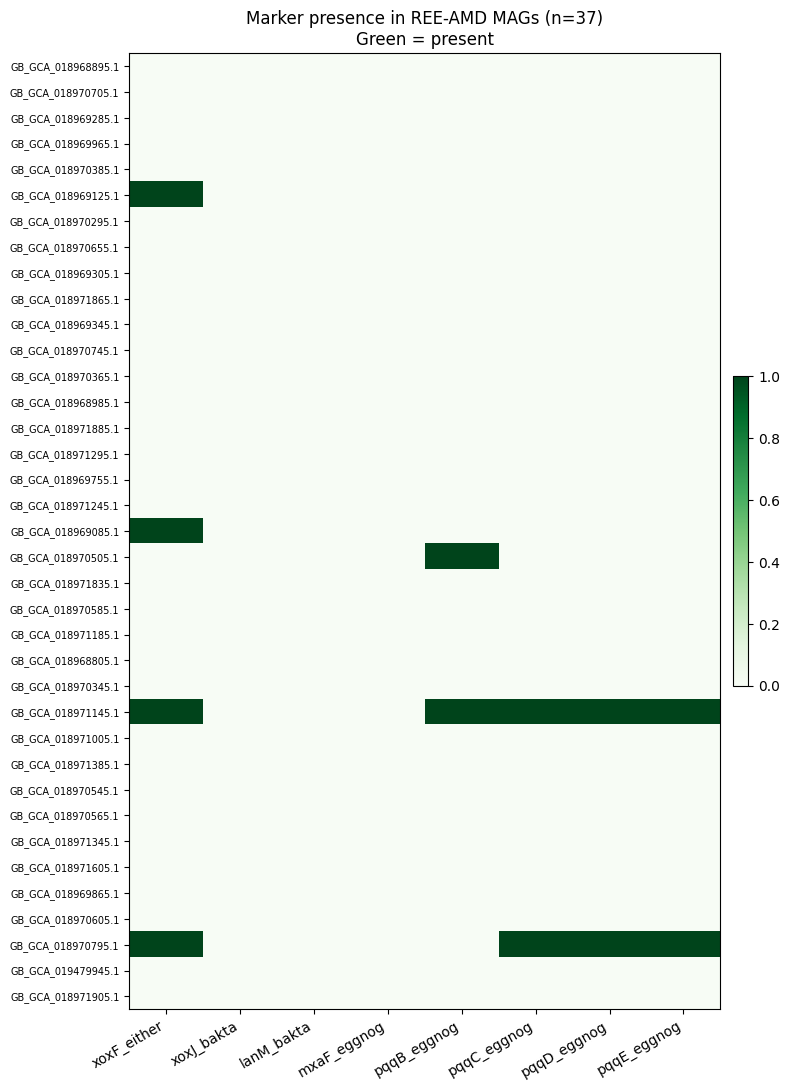

In [7]:
# Figure 2: cassette/marker presence per MAG
order_markers = ["xoxF_either", "xoxJ_bakta", "lanM_bakta", "mxaF_eggnog", "pqqB_eggnog", "pqqC_eggnog", "pqqD_eggnog", "pqqE_eggnog"]
heatmap_df = ree_inv.set_index("genome_id")[order_markers].astype(int)

fig, ax = plt.subplots(figsize=(8, 11))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(order_markers)))
ax.set_xticklabels(order_markers, rotation=30, ha="right")
ax.set_yticks(np.arange(len(heatmap_df)))
ax.set_yticklabels([f"{g[:25]}.." if len(g) > 27 else g for g in heatmap_df.index], fontsize=7)
ax.set_title(f"Marker presence in REE-AMD MAGs (n={len(heatmap_df)})\nGreen = present")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.savefig(FIG / "ree_amd_marker_presence.png", dpi=150)
plt.show()


## 6. Summary

NB06 has descriptively profiled the 37 REE-AMD MAGs:
- Taxonomy is dominated by acidophilic / metal-tolerant lineages, NOT methylotrophs.
- Only 4/37 carry xoxF; 0/37 carry bakta-validated lanmodulin.
- The dominant functional themes (per bakta product field) include acid-resistance, heavy-metal efflux, sulfur oxidation, and oxidative-stress responses — consistent with an acid mine drainage niche.

This case study tempers H2: while xoxF is descriptively elevated in the REE-AMD class, the dominant biology in REE-rich extreme environments is acidophilic metal-tolerance, with lanthanide-MDH presence in only a small minority of the community. NB07 will revisit the PQQ-supply asymmetry (xoxF without PQQ) — the final analysis notebook before synthesis.